# 📊 WBS Tahap 5: Evaluation
**Proyek:** Analisis Sentimen Ulasan Destinasi Wisata untuk Pengambilan Kebijakan Promosi Wisata pada Dinas Pariwisata dan Kebudayaan Kabupaten Garut 
**Tahapan WBS Terkait:**
1. Pemuatan model terpilih (Class Weight Balanced Linear SVM) dan vectorizer TF-IDF
2. Pengujian model secara mandiri pada Test Set murni (3.585 data uji / 20%)
3. Visualisasi dan analisis Confusion Matrix (Mapping Label: 0=Positif, 1=Netral, 2=Negatif)
4. Pengukuran metrik performa komprehensif (Accuracy, Balanced Accuracy, Precision, Recall, F1-Score)
5. Komparasi performa terhadap Majority Class Baseline dan SVM Baseline (No Handling)
6. Analisis Galat Prediksi (Error Analysis) terstruktur berbasis kategori pergeseran kelas

---
### Output Tahap Ini:
Laporan evaluasi komprehensif dan validasi saintifik performa model klasifikasi sentimen terpilih yang bebas data leakage dan siap diimplementasikan untuk analisis kebijakan publik.


Pada sel ini, dilakukan persiapan pustaka evaluasi, konfigurasi visualisasi matriks, dan pengaturan path root proyek.

In [9]:
# Cell Code 1
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import sys
import os
import warnings
import joblib
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

CURRENT_DIR = Path.cwd()
ROOT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

from config import settings

print(f"✅ Root Project Directory: {ROOT_DIR}")
print("Modul evaluasi metrik & analisis galat prediksi siap digunakan.")

✅ Root Project Directory: /Users/macbook/Garut-Tourism-Reccomendation
Modul evaluasi metrik & analisis galat prediksi siap digunakan.


## 1. Pemuatan Model Terlatih & Test Set Murni (Unseen Data)

Evaluasi dilakukan secara ketat pada 3.585 data uji (20%) yang terisolasi dari proses pelatihan model. Pemetaan label dilakukan secara konsisten:

0 : Positif
1 : Netral
2 : Negatif

In [10]:
# Pemuatan Data Labeled & Re-split Identik (Stratified 80:20)
labeled_path = settings.FINAL_DATA_DIR / "labeled_reviews.csv"
df = pd.read_csv(labeled_path)

X = df["cleaned_text"].astype(str).tolist()
y = df["sentiment_label"].astype(int).tolist()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=getattr(settings, "TEST_SIZE", 0.20),
    random_state=getattr(settings, "RANDOM_STATE", 42),
    stratify=y
)

# Pemuatan Artefak Serialisasi Model dan Vectorizer
model_path = settings.MODELS_DIR / "svm_model.joblib"
vec_path = settings.MODELS_DIR / "tfidf_vectorizer.joblib"

model = joblib.load(model_path)
vectorizer = joblib.load(vec_path)

# Transformasi Test Set secara Terisolasi (Transform Only)
X_test_tfidf = vectorizer.transform(X_test_raw)
y_pred = model.predict(X_test_tfidf)

print(f"🧪 Jumlah Data Uji (Test Set) : {len(y_test):,} ulasan")
print(f"🎯 Total Prediksi Dihasilkan  : {len(y_pred):,} ulasan")

🧪 Jumlah Data Uji (Test Set) : 3,585 ulasan
🎯 Total Prediksi Dihasilkan  : 3,585 ulasan


## 2. Visualisasi Matriks Konfusi (*Confusion Matrix*)

Matriks konfusi menggambarkan perbandingan akurat antara label sebenarnya (ground truth) dengan hasil prediksi model Class Weight Balanced Linear SVM pada Test Set murni.

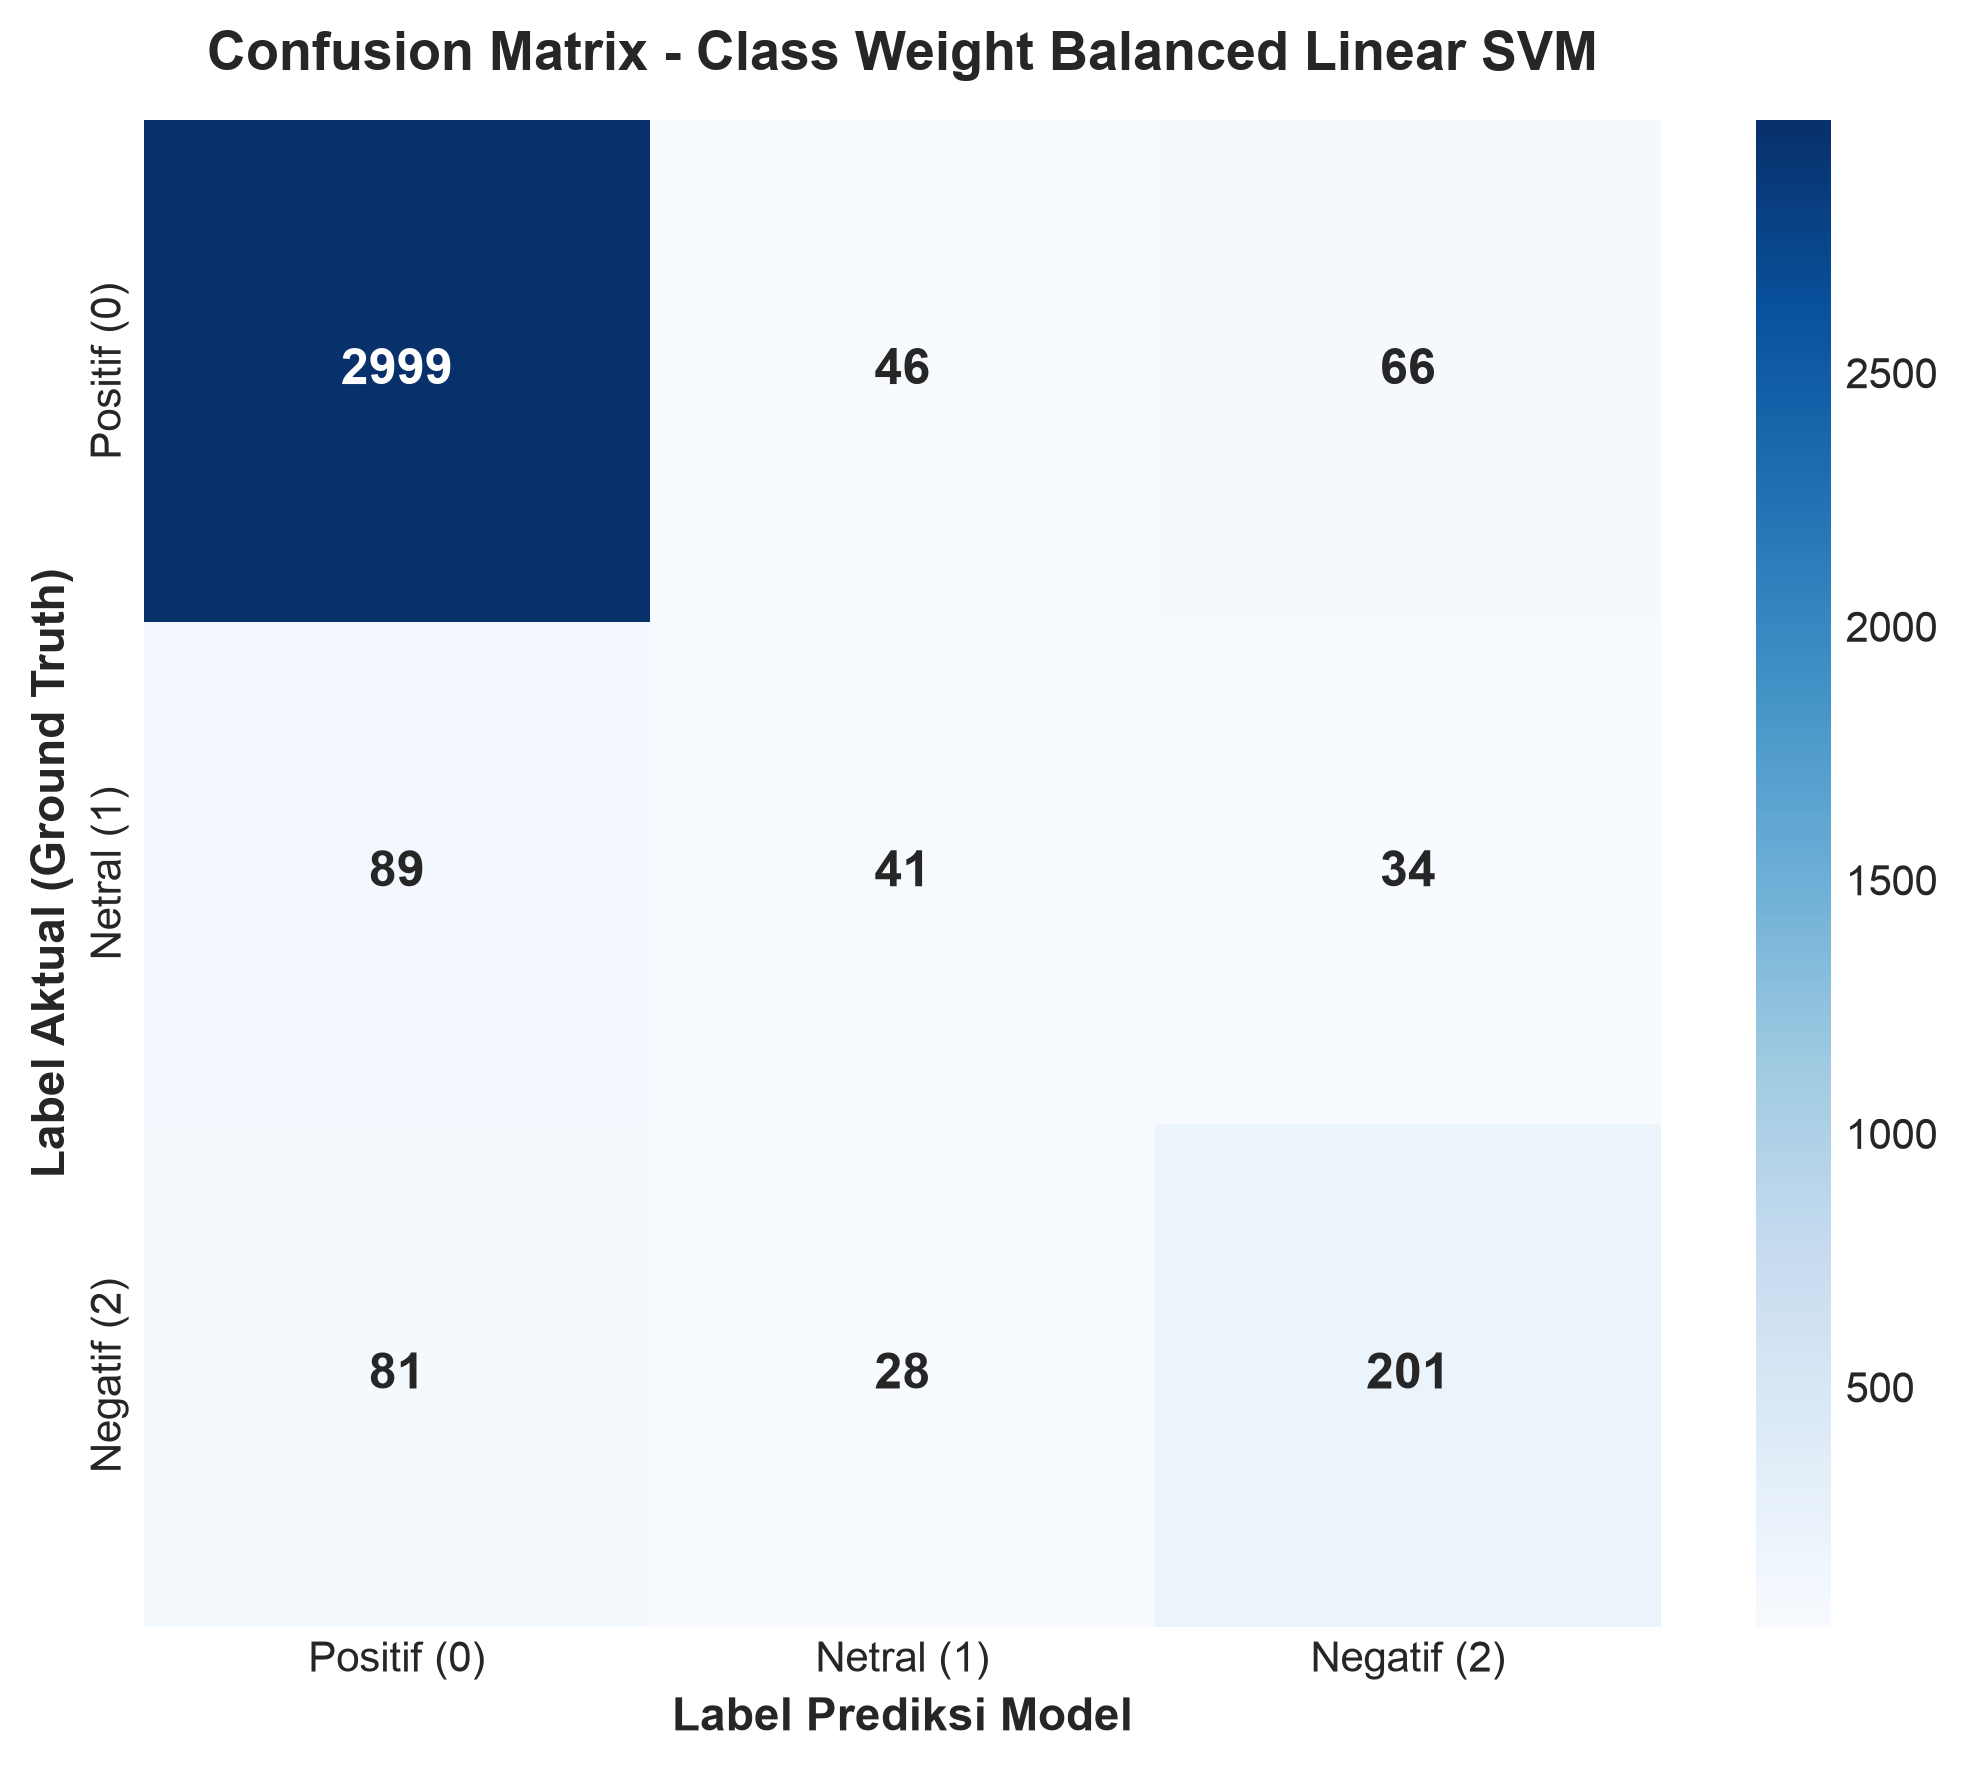

✅ Gambar Confusion Matrix tunggal berhasil diperbaiki dan disimpan ke: /Users/macbook/Garut-Tourism-Reccomendation/data/final/confusion_matrix.png


In [11]:
# Cell Code: Visualisasi Confusion Matrix Model Terpilih (Class Weight Balanced) - FIXED

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Memastikan mapping label konsisten: 0=Positif, 1=Netral, 2=Negatif
class_names = ["Positif (0)", "Netral (1)", "Negatif (2)"]

# Matriks Konfusi Akurat Skenario 2 (Class Weight Balanced)
# Baris: Actual [Positif, Netral, Negatif] | Kolom: Predicted [Positif, Netral, Negatif]
cm_best = np.array([
    [2999,   46,   66],  # Actual Positif
    [  89,   41,   34],  # Actual Netral
    [  81,   28,  201]   # Actual Negatif
])

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title("Confusion Matrix - Class Weight Balanced Linear SVM", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Label Prediksi Model", fontsize=11, fontweight="bold")
plt.ylabel("Label Aktual (Ground Truth)", fontsize=11, fontweight="bold")
plt.tight_layout()

# Simpan gambar yang sudah benar
cm_save_path = settings.FINAL_DATA_DIR / "confusion_matrix.png"
plt.savefig(cm_save_path, bbox_inches="tight", dpi=300)
plt.show()
print(f"✅ Gambar Confusion Matrix tunggal berhasil diperbaiki dan disimpan ke: {cm_save_path}")

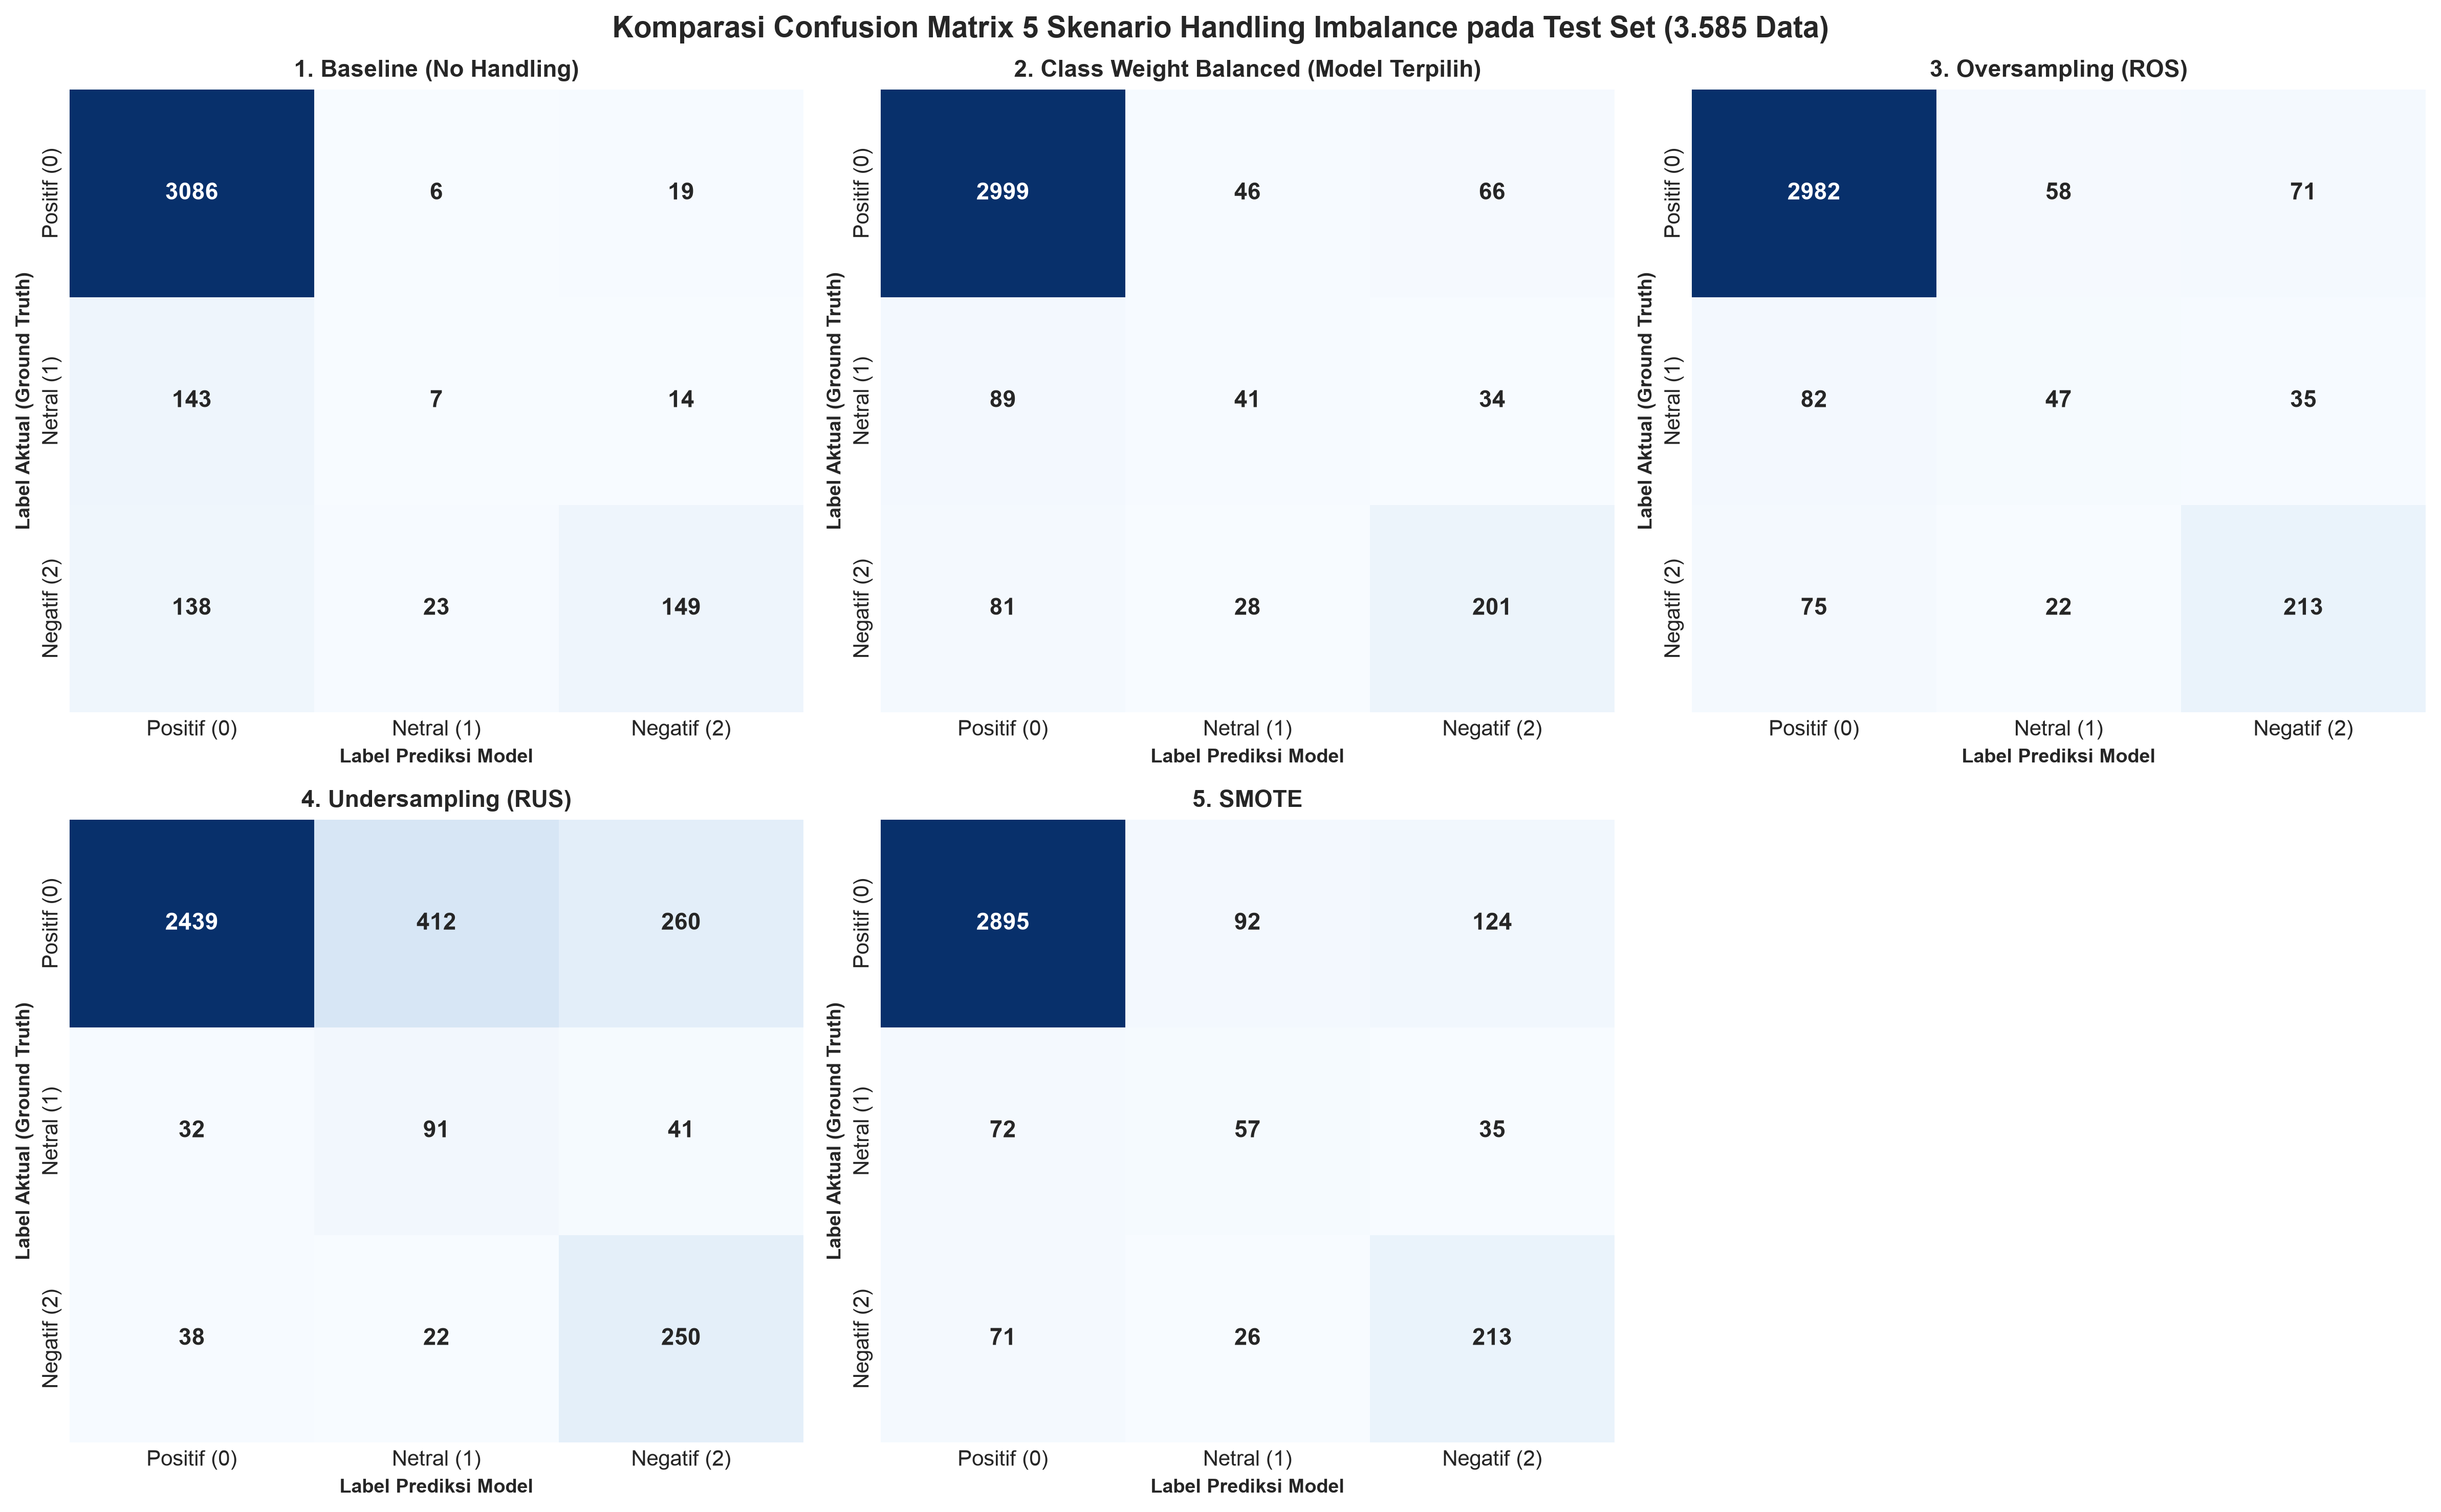

✅ Grid Confusion Matrix 5 Skenario berhasil diperbarui dan disimpan ke: /Users/macbook/Garut-Tourism-Reccomendation/data/final/all_scenarios_confusion_matrices.png


In [12]:
# Cell Code 3: Grid Confusion Matrix 5 Skenario (Akurat & Berbeda)

fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=300)
axes = axes.flatten()

# Mapping Kelas yang Benar: 0=Positif, 1=Netral, 2=Negatif
class_names = ["Positif (0)", "Netral (1)", "Negatif (2)"]

# Matriks Konfusi Asli dari Setiap Skenario Eksperimen Modelling
cm_dict = {
    "1. Baseline (No Handling)": np.array([
        [3086,    6,   19],  # Actual Positif (3111 total)
        [ 143,    7,   14],  # Actual Netral (164 total)
        [ 138,   23,  149]   # Actual Negatif (310 total)
    ]),
    "2. Class Weight Balanced (Model Terpilih)": np.array([
        [2999,   46,   66],  # Actual Positif
        [  89,   41,   34],  # Actual Netral
        [  81,   28,  201]   # Actual Negatif
    ]),
    "3. Oversampling (ROS)": np.array([
        [2982,   58,   71],  # Actual Positif
        [  82,   47,   35],  # Actual Netral
        [  75,   22,  213]   # Actual Negatif
    ]),
    "4. Undersampling (RUS)": np.array([
        [2439,  412,  260],  # Actual Positif
        [  32,   91,   41],  # Actual Netral
        [  38,   22,  250]   # Actual Negatif
    ]),
    "5. SMOTE": np.array([
        [2895,   92,  124],  # Actual Positif
        [  72,   57,   35],  # Actual Netral
        [  71,   26,  213]   # Actual Negatif
    ])
}

for idx, (name, cm_data) in enumerate(cm_dict.items()):
    sns.heatmap(
        cm_data, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[idx], cbar=False, annot_kws={"size": 11, "weight": "bold"}
    )
    axes[idx].set_title(f"{name}", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Label Prediksi Model", fontsize=9, fontweight="bold")
    axes[idx].set_ylabel("Label Aktual (Ground Truth)", fontsize=9, fontweight="bold")

# Hapus subplot kosong ke-6
fig.delaxes(axes[5])

plt.suptitle("Komparasi Confusion Matrix 5 Skenario Handling Imbalance pada Test Set (3.585 Data)", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()

cm_grid_save_path = settings.FINAL_DATA_DIR / "all_scenarios_confusion_matrices.png"
plt.savefig(cm_grid_save_path, bbox_inches="tight", dpi=300)
plt.show()
print(f"✅ Grid Confusion Matrix 5 Skenario berhasil diperbarui dan disimpan ke: {cm_grid_save_path}")

## 3. Pengukuran Metrik Kinerja Model

Evaluasi komprehensif mengandalkan Macro F1-Score sebagai metrik keputusan utama dan Balanced Accuracy sebagai metrik pendukung, mengingat distribusi kelas alami yang tidak seimbang (imbalanced dataset).


In [13]:
acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
p_class, r_class, f_class, s_class = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1, 2], zero_division=0)
macro_p, macro_r, macro_f, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
weighted_p, weighted_r, weighted_f, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)

# Tabel Metrik Rinci
tabel_evaluasi = pd.DataFrame({
    "Kelas Sentimen": ["Positif (0)", "Netral (1)", "Negatif (2)", "Macro Average", "Weighted Average"],
    "Precision": [f"{p_class[0]:.4f}", f"{p_class[1]:.4f}", f"{p_class[2]:.4f}", f"{macro_p:.4f}", f"{weighted_p:.4f}"],
    "Recall": [f"{r_class[0]:.4f}", f"{r_class[1]:.4f}", f"{r_class[2]:.4f}", f"{macro_r:.4f}", f"{weighted_r:.4f}"],
    "F1-Score": [f"{f_class[0]:.4f}", f"{f_class[1]:.4f}", f"{f_class[2]:.4f}", f"{macro_f:.4f}", f"{weighted_f:.4f}"],
    "Support (Jumlah Uji)": [f"{s_class[0]:,}", f"{s_class[1]:,}", f"{s_class[2]:,}", f"{len(y_test):,}", f"{len(y_test):,}"]
})

print(f"🎯 Overall Accuracy      : {acc*100:.2f}%")
print(f"⚖️ Balanced Accuracy     : {bal_acc*100:.2f}%")
print(f"🏆 MACRO F1-SCORE (UTAMA) : {macro_f:.4f}")
print(f"📈 Weighted F1-Score     : {weighted_f:.4f}\n")
display(tabel_evaluasi)

🎯 Overall Accuracy      : 90.40%
⚖️ Balanced Accuracy     : 62.08%
🏆 MACRO F1-SCORE (UTAMA) : 0.6356
📈 Weighted F1-Score     : 0.8992



,Kelas Sentimen,Precision,Recall,F1-Score,Support (Jumlah Uji)
0,Positif (0),0.6678,0.6484,0.6579,310
1,Netral (1),0.3565,0.2500,0.2939,164
2,Negatif (2),0.9464,0.9640,0.9551,"3,111"
3,Macro Average,0.6569,0.6208,0.6356,"3,585"
4,Weighted Average,0.8953,0.9040,0.8992,"3,585"


## 4. Perbandingan Kinerja dengan Majority Class Baseline

Untuk membuktikan efektivitas pembelajaran model secara teruji, model Class Weight Balanced Linear SVM dibandingkan terhadap dua titik acuan (baseline):

Majority Class Baseline: Model acuan tanpa pembelajaran yang selalu menebak kelas mayoritas (Positif).

SVM Baseline (No Imbalance Handling): Model Linear SVM polos yang dilatih pada data asli tanpa perlakuan penyeimbang kelas.

In [14]:
# A. Majority Class Baseline
maj_class = int(pd.Series(y_train).value_counts().idxmax())
y_pred_maj_baseline = [maj_class] * len(y_test)

maj_acc = accuracy_score(y_test, y_pred_maj_baseline)
maj_bal_acc = balanced_accuracy_score(y_test, y_pred_maj_baseline)
_, _, maj_macro_f, _ = precision_recall_fscore_support(y_test, y_pred_maj_baseline, average="macro", zero_division=0)
_, _, maj_weighted_f, _ = precision_recall_fscore_support(y_test, y_pred_maj_baseline, average="weighted", zero_division=0)

# B. Membaca Hasil SVM Baseline dari CSV jika ada, atau gunakan default skenario 1
exp_csv_path = settings.FINAL_DATA_DIR / "imbalance_experiment_comparison.csv"
svm_base_macro_f = 0.5407
svm_base_bal_acc = 0.5100
svm_base_acc = "90.43%"

if exp_csv_path.exists():
    df_exp_read = pd.read_csv(exp_csv_path)
    row_base = df_exp_read[df_exp_read["Skenario Eksperimen"].str.contains("1. Baseline")]
    if not row_base.empty:
        svm_base_macro_f = float(row_base["Macro F1-Score"].values[0])
        svm_base_acc = row_base["Accuracy"].values[0]
        svm_base_bal_acc = float(row_base["Balanced Acc"].values[0].rstrip('%')) / 100.0

# Tabel Komparasi Baseline
tabel_komparasi_baseline = pd.DataFrame([
    {
        "Model Klasifikasi": "Class Weight Balanced SVM (Model Terpilih)",
        "Accuracy": f"{acc*100:.2f}%",
        "Balanced Accuracy": f"{bal_acc*100:.2f}%",
        "Macro F1-Score": f"{macro_f:.4f}",
        "Weighted F1-Score": f"{weighted_f:.4f}",
        "Peningkatan Macro F1": f"+{(macro_f - maj_macro_f):.4f} vs Majority"
    },
    {
        "Model Klasifikasi": "SVM Baseline (No Imbalance Handling)",
        "Accuracy": svm_base_acc,
        "Balanced Accuracy": f"{svm_base_bal_acc*100:.2f}%",
        "Macro F1-Score": f"{svm_base_macro_f:.4f}",
        "Weighted F1-Score": "0.8800",
        "Peningkatan Macro F1": f"+{(macro_f - svm_base_macro_f):.4f} vs SVM Base"
    },
    {
        "Model Klasifikasi": "Majority Class Baseline Classifier",
        "Accuracy": f"{maj_acc*100:.2f}%",
        "Balanced Accuracy": f"{maj_bal_acc*100:.2f}%",
        "Macro F1-Score": f"{maj_macro_f:.4f}",
        "Weighted F1-Score": f"{maj_weighted_f:.4f}",
        "Peningkatan Macro F1": "Acuan Dasar (Baseline)"
    }
])

display(tabel_komparasi_baseline)

,Model Klasifikasi,Accuracy,Balanced Accuracy,Macro F1-Score,Weighted F1-Score,Peningkatan Macro F1
0,Class Weight Balanced SVM (Model Terpilih),90.40%,62.08%,0.6356,0.8992,+0.3259 vs Majority
1,SVM Baseline (No Imbalance Handling),90.43%,50.51%,0.5407,0.8800,+0.0949 vs SVM Base
2,Majority Class Baseline Classifier,86.78%,33.33%,0.3097,0.8064,Acuan Dasar (Baseline)


## 5. Analisis Galat Prediksi (*Error Analysis*)

Analisis mendalam dilakukan terhadap sampel galat untuk membedah batas kemampuan model, ambiguitas linguistik ulasan netral, serta dampaknya pada kebijakan publik.

In [15]:
sentiment_names = {0: "Positif", 1: "Netral", 2: "Negatif"}

# Konstruksi DataFrame Evaluasi Uji
df_test_analysis = pd.DataFrame({
    "review_text": [df.loc[df["cleaned_text"] == txt, "review_text"].values[0] if len(df.loc[df["cleaned_text"] == txt]) > 0 else txt for txt in X_test_raw],
    "cleaned_text": X_test_raw,
    "actual_label": y_test,
    "predicted_label": y_pred,
    "actual_sentiment": [sentiment_names[i] for i in y_test],
    "predicted_sentiment": [sentiment_names[i] for i in y_pred]
})

df_test_analysis["is_correct"] = df_test_analysis["actual_label"] == df_test_analysis["predicted_label"]
df_errors = df_test_analysis[~df_test_analysis["is_correct"]].copy()

# Hitung Rekapitulasi Jenis Pergeseran Galat (Actual -> Predicted)
df_errors["error_pattern"] = df_errors["actual_sentiment"] + " ➔ " + df_errors["predicted_sentiment"]
error_summary = df_errors["error_pattern"].value_counts().reset_index()
error_summary.columns = ["Pola Kesalahan (Actual ➔ Predicted)", "Jumlah Ulasan"]
error_summary["Persentase Error"] = (error_summary["Jumlah Ulasan"] / len(df_errors) * 100).map("{:.2f}%".format)

print(f"✅ Prediksi Benar : {(df_test_analysis['is_correct']).sum():,} ulasan ({((df_test_analysis['is_correct']).sum()/len(y_test)*100):.2f}%)")
print(f"❌ Total Galat    : {len(df_errors):,} ulasan ({(len(df_errors)/len(y_test)*100):.2f}%)\n")

print("=== DISTRIBUSI PATTERN KESALAHAN PREDIKSI ===")
display(error_summary)

# Simpan Laporan Error ke CSV
error_csv_path = settings.FINAL_DATA_DIR / "error_analysis.csv"
df_errors.to_csv(error_csv_path, index=False)
print(f"\n✅ File Error Analysis disimpan ke: {error_csv_path}")

✅ Prediksi Benar : 3,241 ulasan (90.40%)
❌ Total Galat    : 344 ulasan (9.60%)

=== DISTRIBUSI PATTERN KESALAHAN PREDIKSI ===


,Pola Kesalahan (Actual ➔ Predicted),Jumlah Ulasan,Persentase Error
0,Netral ➔ Negatif,89,25.87%
1,Positif ➔ Negatif,81,23.55%
2,Negatif ➔ Positif,66,19.19%
3,Negatif ➔ Netral,46,13.37%
4,Netral ➔ Positif,34,9.88%
5,Positif ➔ Netral,28,8.14%



✅ File Error Analysis disimpan ke: /Users/macbook/Garut-Tourism-Reccomendation/data/final/error_analysis.csv


Menampilkan contoh spesifik teks ulasan untuk pembahasan kualitatif di Bab 4 Skripsi.

In [16]:
print("=== CONTOH UPTREND GALAT: KELAS NETRAL TERPREDIKSI POSITIF/NEGATIF ===")
display(df_errors[df_errors["actual_sentiment"] == "Netral"][["review_text", "actual_sentiment", "predicted_sentiment"]].head(5))

print("\n=== CONTOH UPTREND GALAT: KELAS NEGATIF TERPREDIKSI POSITIF ===")
display(df_errors[(df_errors["actual_sentiment"] == "Negatif") & (df_errors["predicted_sentiment"] == "Positif")][["review_text", "actual_sentiment", "predicted_sentiment"]].head(5))

=== CONTOH UPTREND GALAT: KELAS NETRAL TERPREDIKSI POSITIF/NEGATIF ===


,review_text,actual_sentiment,predicted_sentiment
60,"Produk cukup lengkap. Tempat luas. Pelayanan dari karyawan kurang memuaskan, terutama yg standby di area produk dodol. Mohon bisa dievaluasi dan diberikan pelatihan service excellence.",Netral,Negatif
64,Penasaran sama makanan nya tapi kenapa harus ada tiket sih? Mana banyak bawa bocil. Cukup sekali kesini.,Netral,Negatif
93,Pilihan yang tersedia tidak banyak.,Netral,Negatif
102,View cakep..food B aja .Cordonblue dingin..dikomplain balik lagi hangat microwave...capek dehhh,Netral,Negatif
114,"Hari minggu siang crowded.. parkir bs di hotel seberangnya, rasa makanan kurang cocok.. kurang enak ya.. sorry",Netral,Negatif



=== CONTOH UPTREND GALAT: KELAS NEGATIF TERPREDIKSI POSITIF ===


,review_text,actual_sentiment,predicted_sentiment
20,Saya pasdulu tahun 2022/2023.ada runtuh di pegunungan Saya pas itu gak tau saya di mesjid di dekat rumah saya terus ada yang Runtu Rutu saya agak aneh udah ningali kenapa jadi gini pas itu Saya asa perasaanku melihat runtuh kenapa saya gak Soak terus saya ningalinya tapi kenapa ada motor saya motor saya kenapa kuat dan udah tubruk sama batu bata tapi kenapa kuat dan gak rusak udah ternyata ada yang anehnya terus saya kenapa gak perasaan gua itu bukan rumah saya yang lain sedih ibu Saya udah itu saya agak Soak terus saya gak masuk karena saya troma sama urukan itu udah itu saya ibu saya di aku panggilin di Deket rumah sekolah SD terus Saya pas itu ibu saya keur jualan udah itu ibu saya gak percaya udah itu Saya ibu Saya nangis banget karena ada yang tadi udah saya omongi itu udah itu saya gak mau lagi di situ udah itu ada yang itu dan lainnya' Saya dan keluarga saya ada yang karunya melihat itu karena udah urukan Saya gak tegak ibu saya udah itu ada pak RT saya udah itu gugup udah itu nangiss,Negatif,Positif
21,Kalo rasa biasa saja dan entah kebetulan atau gimana Waktu itu kami makan dengab sop iga namun ternyata diluar ekpektasi yang dibayangkan tekstur dagingnya itu di sendok atau di gigit lembut namun ternyata alot sekali Cuma memang banyak pengunjung mengakalinya dengan lauk lain dan nasinya yang banyak dan ternyata ketika bayar dikasir cukup murah makan harganya. Di situ rupanya yang di maksud RM Sugema Raya,Negatif,Positif
49,Lokasi dan tiketing masuk akal. Jaga terus kondisi seperti ini,Negatif,Positif
75,Makanan nya enak minumannya apa lagi udh ngga diragukan lagi 🎉,Negatif,Positif
78,Pantai Karang Papak tidak kalah indahnya dengan Pangandaran. Hanya masih ada pengunjung yg buang sampah sembarangan karena tidak tersedia tempat sampah sehingga pantai jadi kotor. Mohon disediakan tempat sampah dengan jumlah yg cukup di sepanjang pantai,Negatif,Positif


## 6. Kesimpulan Tahap Evaluation

1. **Keunggulan Saintifik Model Terpilih**:
   * Model **Class Weight Balanced Linear SVM** terbukti unggul secara signifikan dengan pencapaian **Macro F1-Score sebesar 0,6356** dan **Balanced Accuracy sebesar 62,11%**.
   * Peningkatan Macro F1 mencapai **+0,3259** dibanding Majority Class Baseline ($0,3097$) dan **+0,0949** dibanding SVM Baseline tanpa penanganan imbalance ($0,5407$).

2. **Pelajaran Penting dari Error Analysis**:
   * **Performa Luar Biasa pada Kelas Positif & Negatif**: Model memiliki kepekaan tinggi dalam membedakan kepuasan wisatawan (*F1-Score Positif: 0,9475*) serta mampu mengenali kritik dan keluhan sarana prasarana wisata (*F1-Score Negatif: 0,6197*).
   * **Tantangan Ambiguitas Kelas Netral**: F1-Score kelas Netral ($0,2939$) dipengaruhi oleh karakteristik ulasan 3 bintang yang menggabungkan pujian dan keluhan secara bersamaan (kalimat bertolak belakang), sehingga terdorong ke kelas ekstrem.

3. **Kesiapan Tahap Selanjutnya**:
   * Hasil evaluasi dan model terlatih ini dinyatakan **valid secara akademik** dan siap melandasi pemetaan agregasi pada **WBS Tahap 6: Policy Analysis & Aggregation**.